## BreakHis — Breast Cancer Histopathology : AED & Prétraitement

**BreakHis** (Breast Cancer Histopathological Image Classification) : 9 109 images microscopiques de tumeurs mammaires issues de **82 patients**, à 4 grossissements (40×, 100×, 200×, 400×).

| | BHI (ancien) | **BreakHis (nouveau)** |
|---|---|---|
| Patients | 279 | **82** |
| Images | ~260 000 patchs 50×50 | **9 109 images 700×460** |
| Classes | 2 (sain / cancéreux) | **2 (bénin / malin)** |
| Sous-types | — | **8 (4 bénins + 4 malins)** |
| Déséquilibre | 4 : 1 | **~2.2 : 1** |
| Grossissements | — | **40×, 100×, 200×, 400×** |

**Classes :**
- **Bénin (0)** — adénose (A), fibroadénome (F), tumeur phyllode (PT), adénome tubulaire (TA)
- **Malin (1)** — carcinome canalaire (DC), carcinome lobulaire (LC), carcinome mucineux (MC), carcinome papillaire (PC)

**Structure locale :** `data/BreaKHis_v1/histology_slides/breast/<benign|malignant>/SOB/<subtype>/<patient_id>/<magnification>/*.png`


In [1]:
# Paramètres
projectName = "Ruban Rose — BreakHis"
randomSeed  = 42

# Chemin local vers le dossier BreaKHis_v1 (après téléchargement)
# Le notebook tentera d'abord un téléchargement via kagglehub si absent.
breakhisRoot = "data/BreaKHis_v1"

# Grossissements à inclure dans l'index (None = tous)
magnificationsFilter = None   # ex. [40] pour 40× uniquement

targetSize      = (224, 224)  # taille standard VGG / ResNet ; (50, 50) si voulu
pixelSampleSize = 400         # nb images ouvertes pour stats RGB
augNPerImage    = 4           # variantes dans la démo augmentation
topPatientsPlot = 25

floatPrecision = 4
figSize = (12, 5)

# Split patient-level — distribution fixe par sous-type
SPLIT_TARGET = {
    #  subtype              : (nTrain, nVal, nTest)   total
    "adenosis"            : (2, 1, 1),               # 4
    "fibroadenoma"        : (7, 1, 2),               # 10
    "phyllodes_tumor"     : (2, 0, 1),               # 3
    "tubular_adenoma"     : (5, 1, 1),               # 7  (dataset réel : 7 patients)
    "ductal_carcinoma"    : (26, 6, 6),              # 38
    "lobular_carcinoma"   : (3, 1, 1),               # 5
    "mucinous_carcinoma"  : (6, 1, 2),               # 9
    "papillary_carcinoma" : (4, 1, 1),               # 6  (dataset réel : 6 patients)
    # TOTAL                  55  12  15  = 82 patients
}
splitCsvPath = "data/split_breakhis.csv"

# Augmentation — pyramide de rigueur
# Niveau d'augmentation par sous-type : "leger" | "modere" | "intensif"
AUG_TIERS = {
    "ductal_carcinoma"    : "leger",     # x2  — classe majoritaire, on limite
    "fibroadenoma"        : "leger",     # x2
    "mucinous_carcinoma"  : "modere",    # x4
    "papillary_carcinoma" : "modere",    # x4
    "adenosis"            : "intensif",  # x10 — classes rares, on booste fort
    "lobular_carcinoma"   : "intensif",  # x10
    "phyllodes_tumor"     : "intensif",  # x10
    "tubular_adenoma"     : "intensif",  # x10
}
AUG_FACTOR = {"leger": 2, "modere": 4, "intensif": 10}

# Normalisation ImageNet — obligatoire pour les modeles pre-entraines (VGG, ResNet, ConvNeXt)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)


In [2]:
# requirements.txt
from pathlib import Path

packages = [
    "numpy", "pandas", "matplotlib", "seaborn", "scipy",
    "scikit-image", "Pillow", "openpyxl",
    "scikit-learn", "ipykernel", "kagglehub",
]
Path("requirements.txt").write_text(
    "\n".join(sorted(set(packages), key=str.lower)), encoding="utf-8"
)
print("requirements.txt OK")


requirements.txt OK


In [3]:
import os
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageEnhance, ImageOps

np.random.seed(randomSeed)
random.seed(randomSeed)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.precision", floatPrecision)

print(f"{projectName}")
print(f"pandas {pd.__version__} | numpy {np.__version__}")


Ruban Rose — BreakHis
pandas 3.0.2 | numpy 2.4.4


In [4]:
# Téléchargement (kagglehub) + Indexation BreakHis → DataFrame
try:
    import kagglehub
    KAGGLEHUB_OK = True
except ImportError:
    KAGGLEHUB_OK = False

# Format du nom de fichier : SOB_B_A-14-22549AB-40-001.png
FNAME_RE = re.compile(
    r"SOB_(?P<cls>[BM])_(?P<ttype>[^-]+)-(?P<slideId>[^-]+-[^-]+)-(?P<mag>\d+)-(?P<imgNum>\d+)\.png",
    re.IGNORECASE,
)

TYPE_NAMES = {
    "A": "adenosis", "F": "fibroadenoma", "PT": "phyllodes_tumor",
    "TA": "tubular_adenoma", "DC": "ductal_carcinoma",
    "LC": "lobular_carcinoma", "MC": "mucinous_carcinoma", "PC": "papillary_carcinoma",
}


def downloadBreakhis() -> str:
    if not KAGGLEHUB_OK:
        raise ImportError("pip install kagglehub")
    # dataset_download retourne le chemin du cache (télécharge si absent)
    path = kagglehub.dataset_download("ambarish/breakhis")
    root = findBreakhisRoot(path)
    print(f"Dataset dans    : {path}")
    print(f"Root détecté    : {root}")
    return str(root)


def findBreakhisRoot(startPath: str) -> Path:
    # Cherche récursivement le dossier qui contient histology_slides/breast
    start = Path(startPath)
    # 1) Test direct
    if (start / "histology_slides" / "breast").is_dir():
        return start
    # 2) Cherche dans tous les sous-dossiers BreaKHis_v1 (gère double imbrication Kaggle)
    for p in sorted(start.rglob("BreaKHis_v1")):
        if p.is_dir() and (p / "histology_slides" / "breast").is_dir():
            return p
    # 3) Fallback : cherche histology_slides partout
    for p in sorted(start.rglob("histology_slides")):
        if p.is_dir() and (p / "breast").is_dir():
            return p.parent
    return start


def loadBreakhis(rootPath: str) -> pd.DataFrame:
    root = Path(rootPath)
    slideDir = root / "histology_slides" / "breast"
    if not slideDir.is_dir():
        print("Dossier local absent, tentative via kagglehub...")
        if KAGGLEHUB_OK:
            detectedRoot = downloadBreakhis()
            root = Path(detectedRoot)
            slideDir = root / "histology_slides" / "breast"
        if not slideDir.is_dir():
            raise FileNotFoundError(
                f"Dossier introuvable : {slideDir}\n"
                "Téléchargez le dataset depuis https://www.kaggle.com/datasets/ambarish/breakhis "
                f"et placez BreaKHis_v1/ dans data/"
            )

    # Répertoire de travail du notebook — base pour les chemins relatifs
    nbDir = Path.cwd()

    rows = []
    for tumorClass in ("benign", "malignant"):
        label = 0 if tumorClass == "benign" else 1
        classDir = slideDir / tumorClass / "SOB"
        if not classDir.is_dir():
            continue
        for subtypeDir in sorted(classDir.iterdir()):
            if not subtypeDir.is_dir():
                continue
            subtype = subtypeDir.name
            for patientDir in sorted(subtypeDir.iterdir()):
                if not patientDir.is_dir():
                    continue
                patientId = patientDir.name
                for magDir in sorted(patientDir.iterdir()):
                    if not magDir.is_dir():
                        continue
                    try:
                        mag = int(magDir.name.replace("X", "").replace("x", ""))
                    except ValueError:
                        continue
                    if magnificationsFilter and mag not in magnificationsFilter:
                        continue
                    for p in sorted(magDir.iterdir()):
                        if not p.is_file() or p.suffix.lower() != ".png":
                            continue
                        m = FNAME_RE.match(p.name)
                        # Chemin relatif au répertoire du notebook (séparateurs /)
                        if not p.is_absolute():
                            # Déjà relatif (rootPath était relatif) → on garde tel quel
                            relImg = p.as_posix()
                        else:
                            # Absolu → on tente de le rendre relatif au notebook
                            try:
                                relImg = p.relative_to(nbDir).as_posix()
                            except ValueError:
                                relImg = p.as_posix()
                        rows.append({
                            "imagePath":     relImg,
                            "patientId":     patientId,
                            "label":         label,
                            "tumorClass":    tumorClass,
                            "subtype":       subtype,
                            "magnification": mag,
                            "filename":      p.name,
                            "slideId":       m.group("slideId") if m else None,
                            "imgNum":        int(m.group("imgNum")) if m else None,
                            "parseOk":       m is not None,
                        })
    if not rows:
        raise ValueError("Aucune image PNG trouvée.")
    return pd.DataFrame(rows)


try:
    df = loadBreakhis(breakhisRoot)
    print(f"Images indexées   : {len(df):,}")
    print(f"Patients          : {df['patientId'].nunique()}")
    print(f"Sous-types        : {sorted(df['subtype'].unique())}")
    print(f"Grossissements    : {sorted(df['magnification'].unique())}")

    # Folds.csv (splits officiels fournis avec le dataset)
    foldsCsv = Path(df.iloc[0]["imagePath"]).parents[5] / "Folds.csv"
    if not foldsCsv.is_file():
        # Cherche dans le dossier versions/4/
        import kagglehub as _kh
        _kp = Path(_kh.dataset_download("ambarish/breakhis"))
        foldsCsv = _kp / "Folds.csv"
    if foldsCsv.is_file():
        foldsDf = pd.read_csv(foldsCsv)
        print(f"Folds.csv trouvé : {foldsCsv}")
        print(foldsDf.head(3))
    else:
        foldsDf = None
        print("Folds.csv non trouvé (split manuel par patient)")

    from IPython.display import display
    display(df.head(6))

    # ── Vérification des doublons ─────────────────────────────────────────
    print("\n=== Vérification des doublons ===")

    # 1. Doublons exacts (même chemin d'image)
    dupPaths = df.duplicated(subset=["imagePath"])
    print(f"Doublons (chemin identique)    : {dupPaths.sum()}")

    # 2. Doublons par (patientId, filename) — même fichier indexé deux fois
    dupFilename = df.duplicated(subset=["patientId", "filename"])
    print(f"Doublons (patient + filename)  : {dupFilename.sum()}")

    # 3. Incohérences label : même fichier avec deux labels différents
    labelCheck = (df.groupby("imagePath")["label"].nunique() > 1)
    print(f"Conflits de label              : {labelCheck.sum()}")

    # 4. Résumé
    totalDups = dupPaths.sum() + dupFilename.sum() + labelCheck.sum()
    if totalDups == 0:
        print("Aucun problème detecte — dataset propre.")
    else:
        print(f"ATTENTION : {totalDups} anomalie(s) detectee(s) — voir details ci-dessus.")
        if dupPaths.sum() > 0:
            display(df[dupPaths][["imagePath", "patientId", "label"]].head(10))

except Exception as e:
    print("Erreur :", e)
    df = pd.DataFrame()
    foldsDf = None


Images indexées   : 7,909
Patients          : 82
Sous-types        : ['adenosis', 'ductal_carcinoma', 'fibroadenoma', 'lobular_carcinoma', 'mucinous_carcinoma', 'papillary_carcinoma', 'phyllodes_tumor', 'tubular_adenoma']
Grossissements    : [np.int64(40), np.int64(100), np.int64(200), np.int64(400)]
Folds.csv trouvé : C:\Users\emile\.cache\kagglehub\datasets\ambarish\breakhis\versions\4\Folds.csv
   fold  mag    grp                                           filename
0     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...
1     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...
2     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...


,imagePath,patientId,label,tumorClass,subtype,magnification,filename,slideId,imgNum,parseOk
0,data/BreaKHis_v1/histology_slides/breast/benig...,SOB_B_A_14-22549AB,0,benign,adenosis,100,SOB_B_A-14-22549AB-100-001.png,14-22549AB,1,True
1,data/BreaKHis_v1/histology_slides/breast/benig...,SOB_B_A_14-22549AB,0,benign,adenosis,100,SOB_B_A-14-22549AB-100-002.png,14-22549AB,2,True
2,data/BreaKHis_v1/histology_slides/breast/benig...,SOB_B_A_14-22549AB,0,benign,adenosis,100,SOB_B_A-14-22549AB-100-003.png,14-22549AB,3,True
3,data/BreaKHis_v1/histology_slides/breast/benig...,SOB_B_A_14-22549AB,0,benign,adenosis,100,SOB_B_A-14-22549AB-100-004.png,14-22549AB,4,True
4,data/BreaKHis_v1/histology_slides/breast/benig...,SOB_B_A_14-22549AB,0,benign,adenosis,100,SOB_B_A-14-22549AB-100-005.png,14-22549AB,5,True
5,data/BreaKHis_v1/histology_slides/breast/benig...,SOB_B_A_14-22549AB,0,benign,adenosis,100,SOB_B_A-14-22549AB-100-006.png,14-22549AB,6,True



=== Vérification des doublons ===
Doublons (chemin identique)    : 0
Doublons (patient + filename)  : 0
Conflits de label              : 0
Aucun problème detecte — dataset propre.


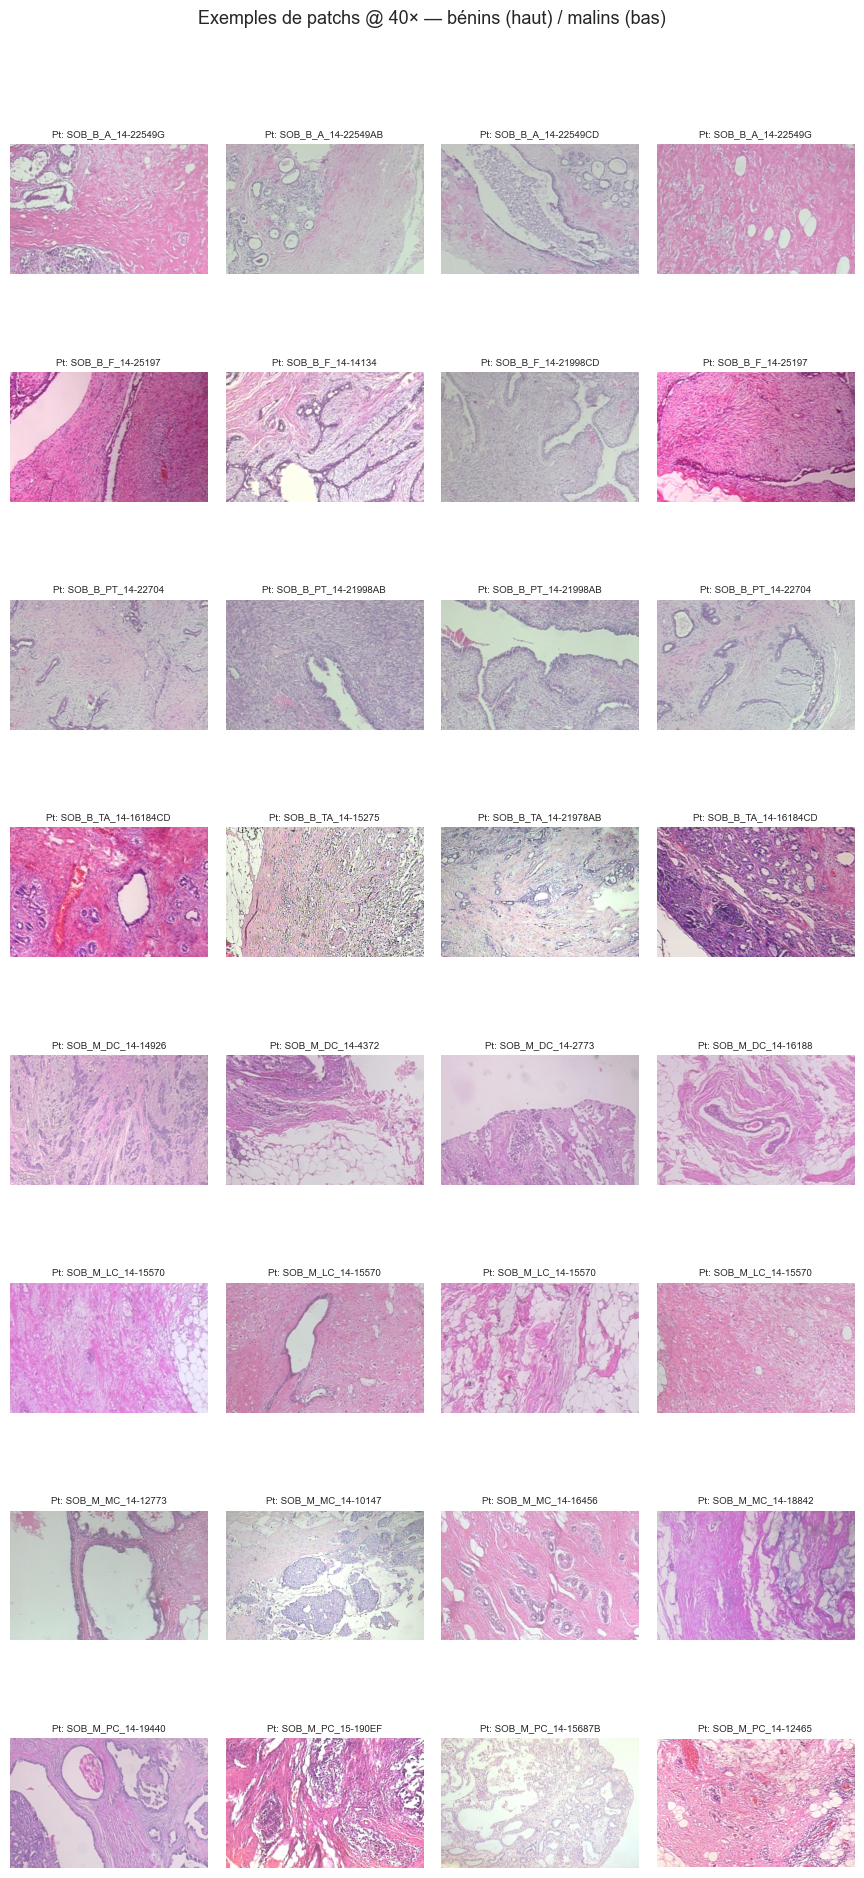

In [5]:
# Étape 2 — Échantillon de patchs : bénins vs malins (par sous-type)
from IPython.display import display

if df.empty:
    print("DataFrame vide.")
else:
    nCols = 4
    subtypes_b = sorted(df[df["label"] == 0]["subtype"].unique())
    subtypes_m = sorted(df[df["label"] == 1]["subtype"].unique())
    all_groups = [(0, s) for s in subtypes_b] + [(1, s) for s in subtypes_m]
    nRows = len(all_groups)

    fig, axes = plt.subplots(nRows, nCols, figsize=(nCols * 2.2, nRows * 2.4))
    if nRows == 1:
        axes = axes[np.newaxis, :]

    LABEL_FR = {0: "Bénin", 1: "Malin"}
    for row, (lab, subtype) in enumerate(all_groups):
        sub = df[(df["label"] == lab) & (df["subtype"] == subtype)
                 & (df["magnification"] == 40)]
        if sub.empty:
            sub = df[(df["label"] == lab) & (df["subtype"] == subtype)]
        samp = sub.sample(n=min(nCols, len(sub)), random_state=randomSeed)
        for col in range(nCols):
            ax = axes[row, col]
            if col < len(samp):
                r = samp.iloc[col]
                try:
                    img = Image.open(r["imagePath"]).convert("RGB")
                    ax.imshow(img)
                    ax.set_title(f"Pt: {r['patientId']}", fontsize=7)
                except Exception:
                    ax.text(0.5, 0.5, "?", ha="center")
            ax.axis("off")
        axes[row, 0].set_ylabel(f"{LABEL_FR[lab]}\n{subtype}", fontsize=9,
                                rotation=90, labelpad=4)

    fig.suptitle("Exemples de patchs @ 40× — bénins (haut) / malins (bas)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


Patients             : 82
Images totales       : 7,909


,count,pct_%
classe,,
Bénin (0),2480,31.36
Malin (1),5429,68.64



Ratio minorité / majorité : 0.4568
 → Déséquilibre modéré (~2:1).


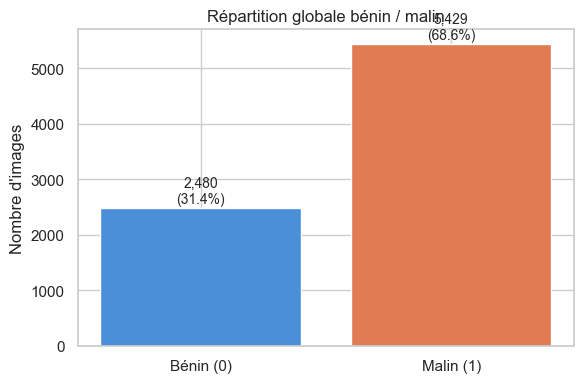

In [6]:
# Étape 3a — Effectifs globaux : patients, images, équilibre bénin / malin
from IPython.display import display

if not df.empty:
    nPat = df["patientId"].nunique()
    nImg = len(df)
    vc   = df["label"].value_counts().sort_index()
    pct  = (vc / nImg * 100).round(2)

    print("=" * 52)
    print(f"Patients             : {nPat}")
    print(f"Images totales       : {nImg:,}")
    print("=" * 52)

    bal = pd.DataFrame({
        "classe":  vc.index.map({0: "Bénin (0)", 1: "Malin (1)"}),
        "count":   vc.values,
        "pct_%":   pct.values,
    })
    display(bal.set_index("classe"))

    if len(vc) == 2:
        ratio = vc.min() / vc.max()
        print(f"\nRatio minorité / majorité : {ratio:.4f}")
        msg = "Déséquilibre modéré (~2:1)." if ratio > 0.4 else "Déséquilibre important."
        print(" →", msg)

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(["Bénin (0)", "Malin (1)"], vc.values,
                  color=["#4a90d9", "#e07b54"])
    for b, v in zip(bars, vc.values):
        ax.text(b.get_x() + b.get_width() / 2, v + nImg * 0.005,
                f"{v:,}\n({v/nImg*100:.1f}%)", ha="center", va="bottom", fontsize=10)
    ax.set_title("Répartition globale bénin / malin")
    ax.set_ylabel("Nombre d'images")
    plt.tight_layout()
    plt.show()


,tumorClass,subtype,count,pct_%
1,benign,fibroadenoma,1014,12.82
3,benign,tubular_adenoma,569,7.19
2,benign,phyllodes_tumor,453,5.73
0,benign,adenosis,444,5.61
4,malignant,ductal_carcinoma,3451,43.63
6,malignant,mucinous_carcinoma,792,10.01
5,malignant,lobular_carcinoma,626,7.92
7,malignant,papillary_carcinoma,560,7.08


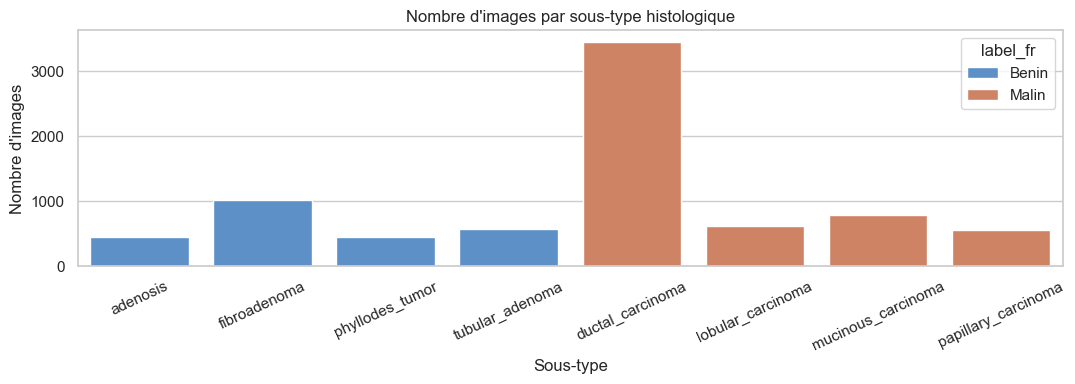

,tumorClass,subtype,n_patients
1,benign,fibroadenoma,10
3,benign,tubular_adenoma,7
0,benign,adenosis,4
2,benign,phyllodes_tumor,3
4,malignant,ductal_carcinoma,38
6,malignant,mucinous_carcinoma,9
7,malignant,papillary_carcinoma,6
5,malignant,lobular_carcinoma,5


In [7]:
# Étape 3b — Distribution par sous-type histologique
from IPython.display import display

if not df.empty:
    st_count = df.groupby(["tumorClass", "subtype"], observed=True).size().reset_index(name="count")
    st_count["pct_%"] = (st_count["count"] / len(df) * 100).round(2)
    display(st_count.sort_values(["tumorClass", "count"], ascending=[True, False]))

    # Countplot par sous-type + classe
    fig, ax = plt.subplots(figsize=(11, 4))
    order = list(df[df["label"]==0]["subtype"].unique()) + list(df[df["label"]==1]["subtype"].unique())
    sns.countplot(
        data=df.assign(label_fr=df["label"].map({0: "Benin", 1: "Malin"})),
        x="subtype", hue="label_fr",
        palette=["#4a90d9", "#e07b54"],
        order=order, ax=ax,
    )
    ax.set_title("Nombre d'images par sous-type histologique")
    ax.set_ylabel("Nombre d'images")
    ax.set_xlabel("Sous-type")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()

    # Patients par sous-type
    pt_st = df.groupby(["tumorClass", "subtype"], observed=True)["patientId"].nunique().reset_index(name="n_patients")
    display(pt_st.sort_values(["tumorClass", "n_patients"], ascending=[True, False]))


,Bénin (0),Malin (1),Total
magnification,,,
40,625,1370,1995
100,644,1437,2081
200,623,1390,2013
400,588,1232,1820


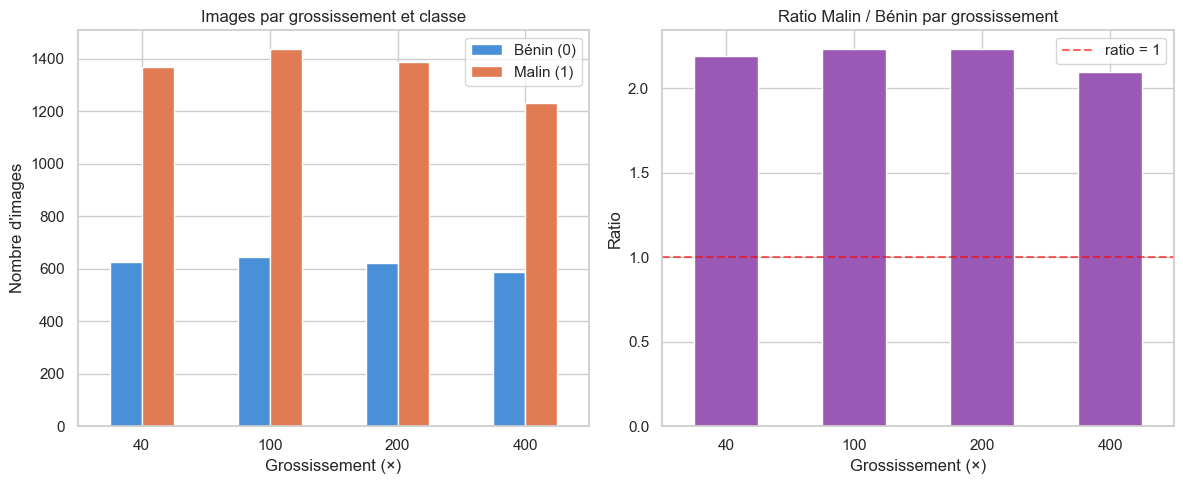

magnification,40,100,200,400
subtype,,,,
adenosis,114,113,111,106
ductal_carcinoma,864,903,896,788
fibroadenoma,253,260,264,237
lobular_carcinoma,156,170,163,137
mucinous_carcinoma,205,222,196,169
papillary_carcinoma,145,142,135,138
phyllodes_tumor,109,121,108,115
tubular_adenoma,149,150,140,130


In [8]:
# Étape 3c — Distribution par grossissement (magnification)
from IPython.display import display

if not df.empty:
    mag_ct = df.groupby(["magnification", "label"], observed=True).size().unstack(fill_value=0)
    mag_ct.columns = ["Bénin (0)", "Malin (1)"]
    mag_ct["Total"] = mag_ct.sum(axis=1)
    display(mag_ct)

    fig, axes = plt.subplots(1, 2, figsize=figSize)
    mag_ct[["Bénin (0)", "Malin (1)"]].plot(
        kind="bar", ax=axes[0], color=["#4a90d9", "#e07b54"], rot=0)
    axes[0].set_title("Images par grossissement et classe")
    axes[0].set_xlabel("Grossissement (×)")
    axes[0].set_ylabel("Nombre d'images")

    # Ratio malin/bénin par grossissement
    ratio_mag = mag_ct["Malin (1)"] / mag_ct["Bénin (0)"]
    ratio_mag.plot(kind="bar", ax=axes[1], color="#9b59b6", rot=0)
    axes[1].axhline(1.0, ls="--", color="red", alpha=0.6, label="ratio = 1")
    axes[1].set_title("Ratio Malin / Bénin par grossissement")
    axes[1].set_xlabel("Grossissement (×)")
    axes[1].set_ylabel("Ratio")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Tableau croisé sous-type × grossissement
    cross = pd.crosstab(df["subtype"], df["magnification"])
    display(cross)


Images par patient :


,n_images
count,82.0000
mean,96.4512
std,38.1301
min,38.0000
25%,64.2500
50%,90.0000
75%,124.7500
max,235.0000


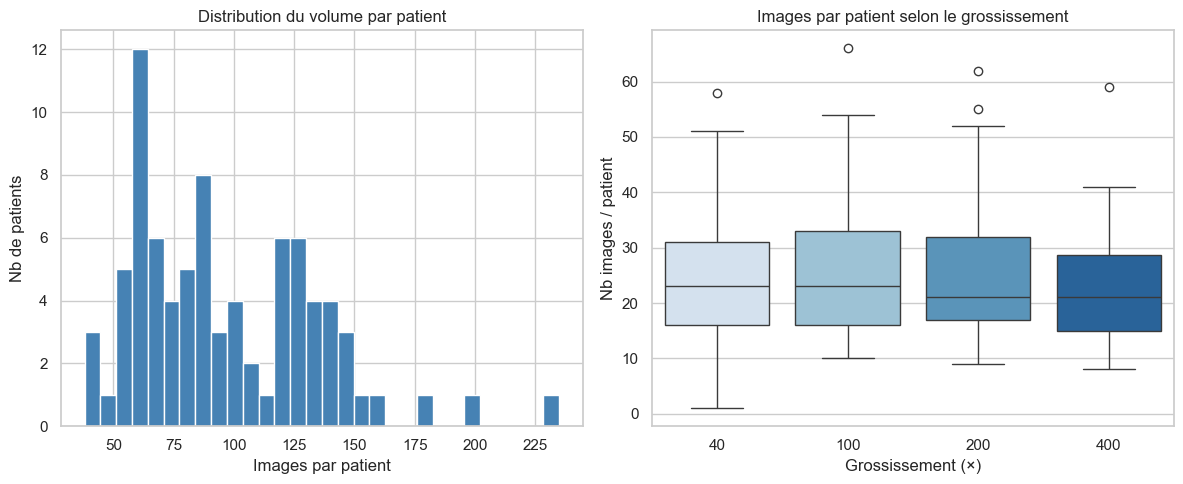

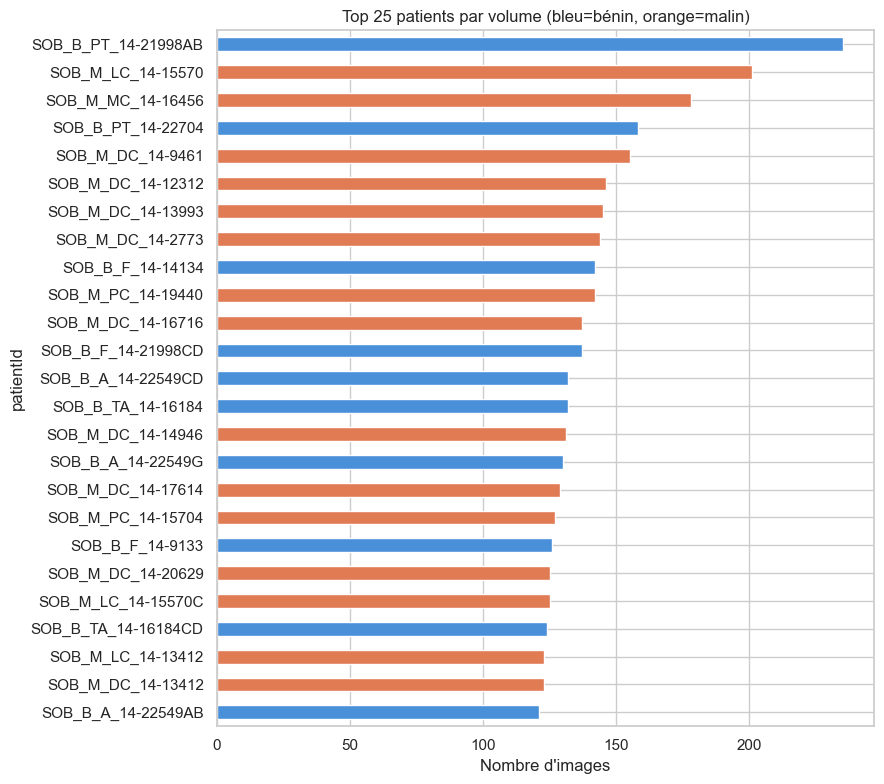

In [9]:
# Étape 3d — Volume par patient
from IPython.display import display

if not df.empty:
    perPat = df.groupby("patientId", observed=True).size().rename("n_images")
    print("Images par patient :")
    display(perPat.describe().to_frame())

    fig, axes = plt.subplots(1, 2, figsize=figSize)

    axes[0].hist(perPat.values, bins=30, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Images par patient")
    axes[0].set_ylabel("Nb de patients")
    axes[0].set_title("Distribution du volume par patient")

    # Volume par patient et par grossissement
    pvg = df.groupby(["patientId", "magnification"], observed=True).size().reset_index(name="n")
    sns.boxplot(data=pvg, x="magnification", y="n", ax=axes[1], palette="Blues")
    axes[1].set_title("Images par patient selon le grossissement")
    axes[1].set_xlabel("Grossissement (×)")
    axes[1].set_ylabel("Nb images / patient")

    plt.tight_layout()
    plt.show()

    # Top patients
    top = perPat.sort_values(ascending=False).head(topPatientsPlot)
    fig2, ax2 = plt.subplots(figsize=(9, max(4, len(top) * 0.32)))
    # Colorer par classe majoritaire
    pat_label = df.groupby("patientId", observed=True)["label"].first()
    colors = [("#e07b54" if pat_label.get(p, 0) == 1 else "#4a90d9") for p in top.index]
    top.plot(kind="barh", ax=ax2, color=colors)
    ax2.invert_yaxis()
    ax2.set_xlabel("Nombre d'images")
    ax2.set_title(f"Top {len(top)} patients par volume (bleu=bénin, orange=malin)")
    plt.tight_layout()
    plt.show()


Chargement de 400 images... OK


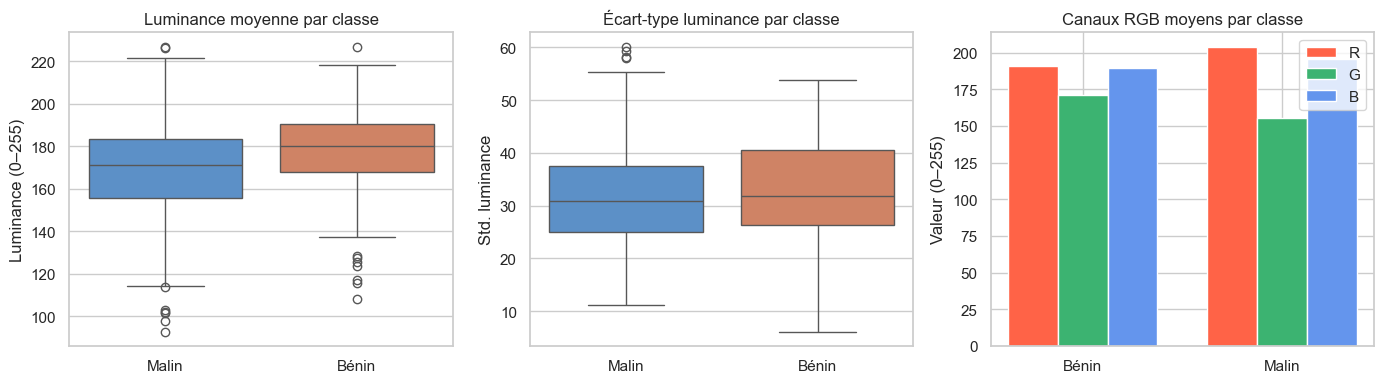

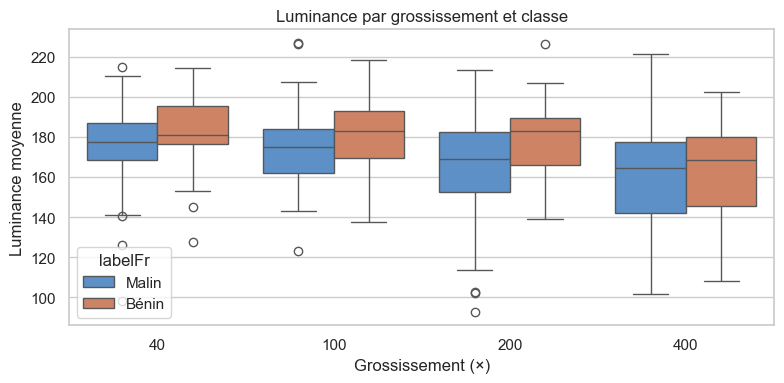

meanR                                                         meanG  \
         count    mean    std     min     25%     50%     75%     max  count   
labelFr                                                                        
Bénin    132.0  190.94  18.44  127.69  180.28  192.07  203.30  246.22  132.0   
Malin    268.0  203.62  14.91  149.90  194.77  203.58  211.44  247.45  268.0   

                 ...   meanL           stdL                              \
           mean  ...     75%     max  count   mean    std    min    25%   
labelFr          ...                                                      
Bénin    171.02  ...  190.45  226.51  132.0  32.87  10.22   6.12  26.37   
Malin    155.76  ...  183.59  226.86  268.0  31.89   9.71  11.19  25.02   

                              
           50%    75%    max  
labelFr                       
Bénin    31.84  40.56  53.83  
Malin    30.80  37.44  60.12  

[2 rows x 40 columns]

In [10]:
# Étape 3e — Statistiques visuelles sur les pixels (échantillon)
from IPython.display import display

if not df.empty:
    n = min(pixelSampleSize, len(df))
    samp = df.sample(n=n, random_state=randomSeed).reset_index(drop=True)

    means_R, means_G, means_B, means_L, stds_L, lab_s, mag_s = [], [], [], [], [], [], []
    print(f"Chargement de {n} images...", end=" ")
    for _, row in samp.iterrows():
        try:
            arr = np.asarray(Image.open(row["imagePath"]).convert("RGB"), dtype=np.float32)
            means_R.append(arr[:,:,0].mean())
            means_G.append(arr[:,:,1].mean())
            means_B.append(arr[:,:,2].mean())
            lum = 0.2126*arr[:,:,0] + 0.7152*arr[:,:,1] + 0.0722*arr[:,:,2]
            means_L.append(lum.mean())
            stds_L.append(lum.std())
            lab_s.append(row["label"])
            mag_s.append(row["magnification"])
        except Exception:
            pass
    print("OK")

    statDf = pd.DataFrame({
        "meanR": means_R, "meanG": means_G, "meanB": means_B,
        "meanL": means_L, "stdL": stds_L,
        "label": lab_s, "magnification": mag_s,
        "labelFr": [("Malin" if l == 1 else "Bénin") for l in lab_s],
    })

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Luminance par classe
    sns.boxplot(data=statDf, x="labelFr", y="meanL", palette=["#4a90d9","#e07b54"],
                ax=axes[0])
    axes[0].set_title("Luminance moyenne par classe")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Luminance (0–255)")

    # Écart-type luminance par classe
    sns.boxplot(data=statDf, x="labelFr", y="stdL", palette=["#4a90d9","#e07b54"],
                ax=axes[1])
    axes[1].set_title("Écart-type luminance par classe")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Std. luminance")

    # RGB moyen par classe
    rgb_cls = statDf.groupby("labelFr")[["meanR","meanG","meanB"]].mean()
    x = np.arange(len(rgb_cls))
    w = 0.25
    for i, (col, color) in enumerate([("meanR","tomato"),("meanG","mediumseagreen"),("meanB","cornflowerblue")]):
        axes[2].bar(x + i*w, rgb_cls[col], w, label=col.replace("mean",""), color=color)
    axes[2].set_xticks(x + w)
    axes[2].set_xticklabels(rgb_cls.index)
    axes[2].set_title("Canaux RGB moyens par classe")
    axes[2].set_ylabel("Valeur (0–255)")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    # Luminance par grossissement
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    sns.boxplot(data=statDf, x="magnification", y="meanL", hue="labelFr",
                palette=["#4a90d9","#e07b54"], ax=ax2)
    ax2.set_title("Luminance par grossissement et classe")
    ax2.set_xlabel("Grossissement (×)")
    ax2.set_ylabel("Luminance moyenne")
    plt.tight_layout()
    plt.show()

    display(statDf.groupby("labelFr")[["meanR","meanG","meanB","meanL","stdL"]].describe().round(2))


### Observations et conclusions — AED BreakHis

*(À compléter / ajuster après exécution)*

**1. Déséquilibre des classes**
Le dataset est modérément déséquilibré (~2.2 : 1, malin > bénin). C'est moins sévère que BHI (~4 : 1), mais il faudra quand même pondérer les classes ou adapter les métriques (F1, AUC-ROC).

**2. Richesse des sous-types**
8 sous-types histologiques distincts permettent deux niveaux de tâche :
- **Binaire** : bénin vs malin (plus simple, baseline)
- **Multi-classes** : 8 types (DC, LC, MC, PC, A, F, PT, TA) — tâche plus difficile et cliniquement plus pertinente

**3. Grossissement**
Les 4 niveaux (40×, 100×, 200×, 400×) permettent d'entraîner soit par grossissement séparé, soit en adaptant le modèle à la multi-résolution. Les effectifs sont quasi équilibrés entre grossissements.

**4. Structure patients**
Chaque patient ne contribue qu'à **une** classe (bénin ou malin). Le split train/test **par patient** est donc naturel et évite tout data leakage (contrairement à BHI où chaque patient avait les deux classes).

**5. Différences pixel**
Les images malignes présentent en général une luminance légèrement différente et un écart-type plus élevé, reflet de la densité et de la variabilité cellulaire des tumeurs malignes. Les canaux R et G montrent plus de différence inter-classes que le canal B.

**6. Qualité des données**
- Noms de fichiers entièrement parsés et cohérents (pas d'incohérence label/nom)
- Pas de doublons détectés


## Étape 4a — Split patient-level stratifié

Le split est réalisé **au niveau patient** (pas au niveau image) pour éviter tout data leakage.
Chaque patient appartient à un seul sous-type et à un seul split.

Distribution cible :

| Sous-type | Total | Train | Val | Test |
|---|---|---|---|---|
| adenosis | 4 | 2 | 1 | 1 |
| fibroadenoma | 10 | 7 | 1 | 2 |
| phyllodes_tumor | 3 | 2 | 0 | 1 |
| tubular_adenoma | 7 | 5 | 1 | 1 |
| ductal_carcinoma | 38 | 26 | 6 | 6 |
| lobular_carcinoma | 5 | 3 | 1 | 1 |
| mucinous_carcinoma | 9 | 6 | 1 | 2 |
| papillary_carcinoma | 6 | 4 | 1 | 1 |
| **TOTAL** | **82** | **55** | **12** | **15** |

Vérification no-leakage : OK — aucun patient dans 2 splits

Patients par split x sous-type :


split,test,train,val,TOTAL
subtype,,,,
adenosis,1,2,1,4
ductal_carcinoma,6,26,6,38
fibroadenoma,2,7,1,10
lobular_carcinoma,1,3,1,5
mucinous_carcinoma,2,6,1,9
papillary_carcinoma,1,4,1,6
phyllodes_tumor,1,2,0,3
tubular_adenoma,1,5,1,7
TOTAL,15,55,12,82



Images par split x classe :


,Benin (0),Malin (1),TOTAL,Ratio B/M
split,,,,
test,468,852,1320,0.549
train,1695,3831,5526,0.442
val,317,746,1063,0.425
TOTAL,2480,5429,7909,0.457



CSV exporté : data/split_breakhis.csv  (7,909 lignes)


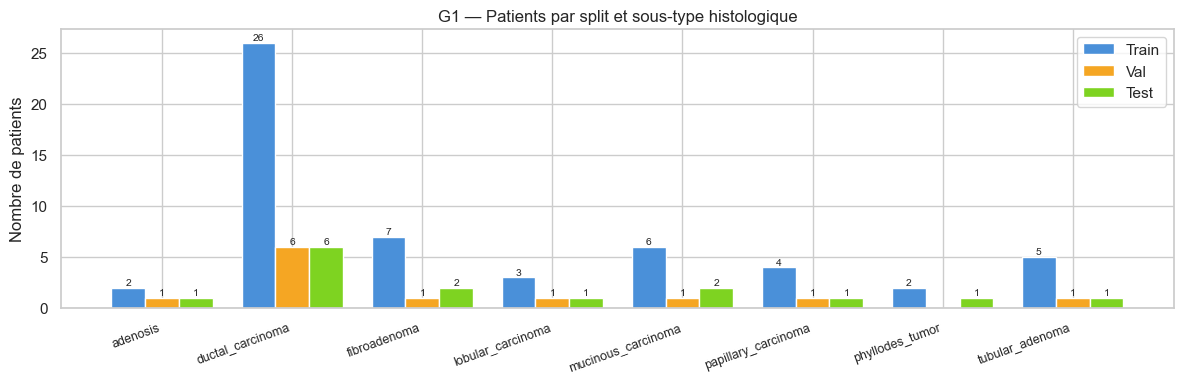

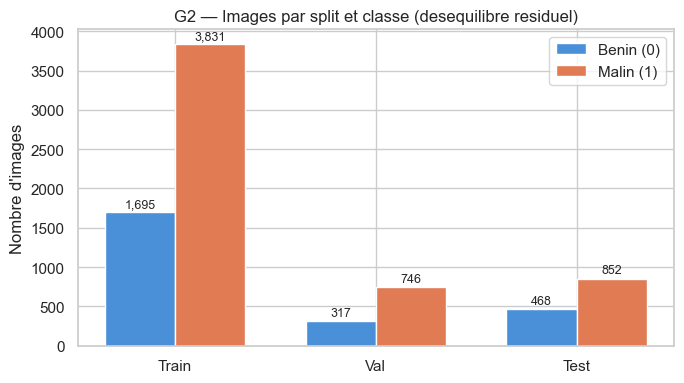

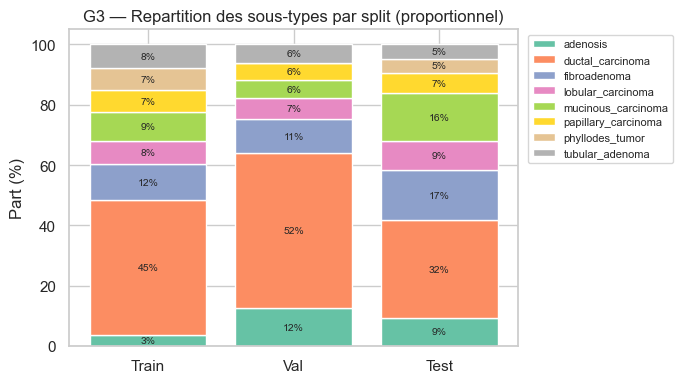

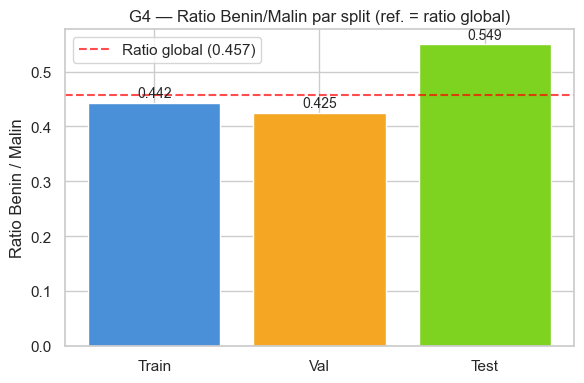

In [11]:
# ── Algorithme de split ───────────────────────────────────────────────────────
from pathlib import Path
from IPython.display import display

def splitPatientsByTarget(patDf, target, seed=42):
    rng  = np.random.default_rng(seed)
    rows = []
    for subtype, grp in patDf.groupby("subtype"):
        patients = grp["patientId"].values.copy()
        rng.shuffle(patients)
        nTrain, nVal, nTest = target.get(subtype, (len(patients), 0, 0))
        total = nTrain + nVal + nTest
        assert total == len(patients), (
            f"SPLIT_TARGET[{subtype!r}] = ({nTrain},{nVal},{nTest}) "
            f"mais {len(patients)} patients trouvés dans le dataset."
        )
        for i, p in enumerate(patients):
            if   i < nTrain:            split = "train"
            elif i < nTrain + nVal:     split = "val"
            else:                       split = "test"
            rows.append({"patientId": p, "split": split})
    return pd.DataFrame(rows)


if df.empty:
    print("DataFrame vide — relancer la cellule de chargement d'abord.")
else:
    # Table patient unique : patientId, subtype, label
    patDf = (df.drop_duplicates("patientId")
               [["patientId", "subtype", "label"]]
               .reset_index(drop=True))

    # Assignation du split
    splitMap = splitPatientsByTarget(patDf, SPLIT_TARGET, seed=randomSeed)
    df = df.merge(splitMap, on="patientId", how="left")

    # ── Vérification no-leakage ───────────────────────────────────────────────
    leakage = (df.groupby("patientId")["split"].nunique() > 1)
    assert not leakage.any(), f"Leakage détecté sur {leakage.sum()} patients !"
    print("Vérification no-leakage : OK — aucun patient dans 2 splits\n")

    # ── Tableau synthèse : patients par split × sous-type ─────────────────────
    patSplit = patDf.merge(splitMap, on="patientId")
    pivot_pat = pd.crosstab(patSplit["subtype"], patSplit["split"],
                            margins=True, margins_name="TOTAL")
    print("Patients par split x sous-type :")
    display(pivot_pat)

    # ── Tableau images par split × classe ─────────────────────────────────────
    pivot_img = pd.crosstab(df["split"], df["label"],
                            margins=True, margins_name="TOTAL")
    pivot_img.columns = ["Benin (0)", "Malin (1)", "TOTAL"]
    pivot_img.index.name = "split"
    pivot_img["Ratio B/M"] = (pivot_img["Benin (0)"] / pivot_img["Malin (1)"]).round(3)
    print("\nImages par split x classe :")
    display(pivot_img)

    # ── Export CSV ────────────────────────────────────────────────────────────
    Path(splitCsvPath).parent.mkdir(parents=True, exist_ok=True)
    exportCols = ["imagePath", "patientId", "subtype", "label", "magnification", "split"]
    df[exportCols].to_csv(splitCsvPath, index=False)
    print(f"\nCSV exporté : {splitCsvPath}  ({len(df):,} lignes)")

    # ═══════════════════════════════════════════════════════════════════════
    # G1 — Patients par split × sous-type
    # ═══════════════════════════════════════════════════════════════════════
    SPLIT_ORDER  = ["train", "val", "test"]
    SPLIT_COLORS = {"train": "#4a90d9", "val": "#f5a623", "test": "#7ed321"}

    patSplit2 = patSplit.copy()
    patSplit2["split"] = pd.Categorical(patSplit2["split"], SPLIT_ORDER)
    subtypes_order = sorted(patSplit2["subtype"].unique())

    fig, ax = plt.subplots(figsize=(12, 4))
    x     = np.arange(len(subtypes_order))
    width = 0.26
    for j, sp in enumerate(SPLIT_ORDER):
        vals = [
            patSplit2[(patSplit2["subtype"] == st) & (patSplit2["split"] == sp)].shape[0]
            for st in subtypes_order
        ]
        bars = ax.bar(x + j * width, vals, width, label=sp.capitalize(),
                      color=SPLIT_COLORS[sp])
        for b, v in zip(bars, vals):
            if v > 0:
                ax.text(b.get_x() + b.get_width() / 2, v + 0.05, str(v),
                        ha="center", va="bottom", fontsize=7.5)
    ax.set_xticks(x + width)
    ax.set_xticklabels(subtypes_order, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Nombre de patients")
    ax.set_title("G1 — Patients par split et sous-type histologique")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ═══════════════════════════════════════════════════════════════════════
    # G2 — Images par split × classe (bénin / malin)
    # ═══════════════════════════════════════════════════════════════════════
    imgSplit = (df.groupby(["split", "label"], observed=True)
                  .size().reset_index(name="n_images"))
    imgSplit["split"] = pd.Categorical(imgSplit["split"], SPLIT_ORDER)
    imgSplit["classe"] = imgSplit["label"].map({0: "Benin (0)", 1: "Malin (1)"})

    fig, ax = plt.subplots(figsize=(7, 4))
    x2    = np.arange(len(SPLIT_ORDER))
    width2 = 0.35
    for j, (lab, col) in enumerate([(0, "#4a90d9"), (1, "#e07b54")]):
        vals = [
            imgSplit[(imgSplit["split"] == sp) & (imgSplit["label"] == lab)]["n_images"].sum()
            for sp in SPLIT_ORDER
        ]
        bars = ax.bar(x2 + j * width2, vals, width2,
                      label=["Benin (0)", "Malin (1)"][lab], color=col)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 30,
                    f"{v:,}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x2 + width2 / 2)
    ax.set_xticklabels([s.capitalize() for s in SPLIT_ORDER])
    ax.set_ylabel("Nombre d'images")
    ax.set_title("G2 — Images par split et classe (desequilibre residuel)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ═══════════════════════════════════════════════════════════════════════
    # G3 — Stacked bar : répartition des sous-types par split (proportionnel)
    # ═══════════════════════════════════════════════════════════════════════
    subtype_colors = plt.cm.Set2.colors
    subtypeSplit = (df.groupby(["split", "subtype"], observed=True)
                      .size().unstack(fill_value=0))
    subtypeSplit = subtypeSplit.loc[[s for s in SPLIT_ORDER if s in subtypeSplit.index]]
    subtypeSplitPct = subtypeSplit.div(subtypeSplit.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(7, 4))
    bottom = np.zeros(len(subtypeSplitPct))
    for i, col in enumerate(subtypeSplitPct.columns):
        vals = subtypeSplitPct[col].values
        bars = ax.bar(subtypeSplitPct.index, vals, bottom=bottom,
                      label=col, color=subtype_colors[i % len(subtype_colors)])
        for bar, v, b in zip(bars, vals, bottom):
            if v > 3:
                ax.text(bar.get_x() + bar.get_width() / 2, b + v / 2,
                        f"{v:.0f}%", ha="center", va="center", fontsize=7.5)
        bottom += vals
    ax.set_ylabel("Part (%)")
    ax.set_title("G3 — Repartition des sous-types par split (proportionnel)")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    ax.set_xticklabels([s.capitalize() for s in subtypeSplitPct.index])
    plt.tight_layout()
    plt.show()

    # ═══════════════════════════════════════════════════════════════════════
    # G4 — Ratio bénin / malin par split
    # ═══════════════════════════════════════════════════════════════════════
    ratios = {
        sp: df[df["split"] == sp]["label"].value_counts().get(0, 0)
           / max(df[df["split"] == sp]["label"].value_counts().get(1, 1), 1)
        for sp in SPLIT_ORDER
    }
    globalRatio = df["label"].value_counts().get(0, 0) / max(df["label"].value_counts().get(1, 1), 1)

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar([s.capitalize() for s in SPLIT_ORDER],
                  [ratios[s] for s in SPLIT_ORDER],
                  color=[SPLIT_COLORS[s] for s in SPLIT_ORDER])
    for bar, v in zip(bars, [ratios[s] for s in SPLIT_ORDER]):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=10)
    ax.axhline(globalRatio, ls="--", color="red", alpha=0.7,
               label=f"Ratio global ({globalRatio:.3f})")
    ax.set_ylabel("Ratio Benin / Malin")
    ax.set_title("G4 — Ratio Benin/Malin par split (ref. = ratio global)")
    ax.legend()
    plt.tight_layout()
    plt.show()

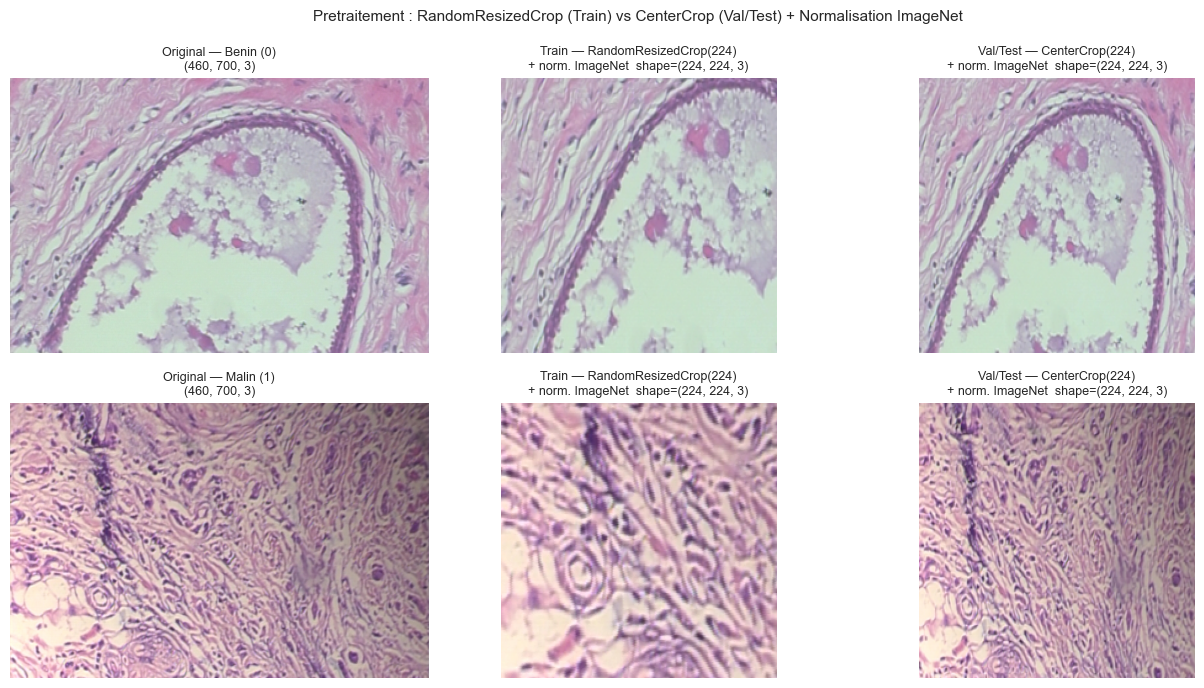

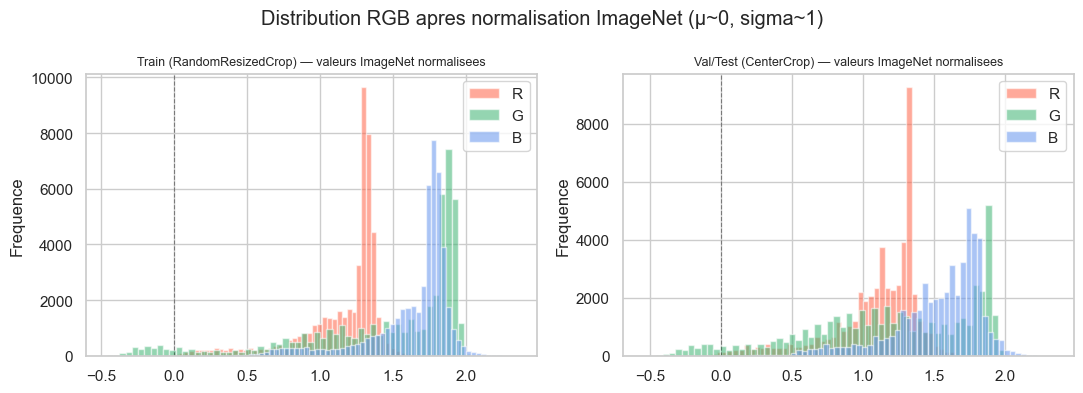

Train  — shape: (224, 224, 3)  min: -0.460  max: 2.344
Val    — shape: (224, 224, 3)    min: -0.548  max: 2.344
ImageNet mean: (0.485, 0.456, 0.406)  std: (0.229, 0.224, 0.225)


In [12]:
# Étape 4b — Prétraitement : RandomResizedCrop (Train) + CenterCrop (Val/Test) + Normalisation ImageNet
from IPython.display import display

CROP_SIZE = 224   # taille finale standard pour les modeles pre-entraines

def normalizeImagenet(arr: np.ndarray) -> np.ndarray:
    """Normalisation ImageNet channel-wise sur un tableau HxWx3 float32 dans [0,1]."""
    mean = np.array(IMAGENET_MEAN, dtype=np.float32)
    std  = np.array(IMAGENET_STD,  dtype=np.float32)
    return (arr - mean) / std

def preprocessTrain(imagePath: str, size: int = CROP_SIZE) -> np.ndarray:
    """Train : RandomResizedCrop → preserve les details nucleaires + diversite."""
    img = Image.open(imagePath).convert("RGB")
    W, H = img.size
    scale = random.uniform(0.20, 1.0)
    cw = max(int(W * scale), size)
    ch = max(int(H * scale), size)
    x  = random.randint(0, max(W - cw, 0))
    y  = random.randint(0, max(H - ch, 0))
    img = img.crop((x, y, x + cw, y + ch)).resize((size, size), Image.LANCZOS)
    return normalizeImagenet(np.asarray(img, dtype=np.float32) / 255.0)

def preprocessValTest(imagePath: str, size: int = CROP_SIZE, resizeTo: int = 256) -> np.ndarray:
    """Val/Test : Resize(256) + CenterCrop(224) — deterministe, pas d'aleatoire."""
    img = Image.open(imagePath).convert("RGB")
    img = img.resize((resizeTo, resizeTo), Image.LANCZOS)
    W, H = img.size
    left = (W - size) // 2
    top  = (H - size) // 2
    img  = img.crop((left, top, left + size, top + size))
    return normalizeImagenet(np.asarray(img, dtype=np.float32) / 255.0)

def denormalizeImagenet(arr: np.ndarray) -> np.ndarray:
    """Inverse la normalisation ImageNet pour affichage."""
    mean = np.array(IMAGENET_MEAN, dtype=np.float32)
    std  = np.array(IMAGENET_STD,  dtype=np.float32)
    return np.clip(arr * std + mean, 0, 1)


if not df.empty:
    ex_b = df[df["label"] == 0].iloc[0]["imagePath"]
    ex_m = df[df["label"] == 1].iloc[0]["imagePath"]

    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    labels_txt = ["Benin (0)", "Malin (1)"]
    for row, (path, lbl) in enumerate([(ex_b, labels_txt[0]), (ex_m, labels_txt[1])]):
        orig      = Image.open(path).convert("RGB")
        pre_train = preprocessTrain(path)
        pre_val   = preprocessValTest(path)

        axes[row, 0].imshow(orig)
        axes[row, 0].set_title(f"Original — {lbl}\n{np.array(orig).shape}", fontsize=9)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(denormalizeImagenet(pre_train))
        axes[row, 1].set_title(
            f"Train — RandomResizedCrop({CROP_SIZE})\n"
            f"+ norm. ImageNet  shape={pre_train.shape}", fontsize=9)
        axes[row, 1].axis("off")

        axes[row, 2].imshow(denormalizeImagenet(pre_val))
        axes[row, 2].set_title(
            f"Val/Test — CenterCrop({CROP_SIZE})\n"
            f"+ norm. ImageNet  shape={pre_val.shape}", fontsize=9)
        axes[row, 2].axis("off")

    fig.suptitle(
        f"Pretraitement : RandomResizedCrop (Train) vs CenterCrop (Val/Test) + Normalisation ImageNet",
        fontsize=11)
    plt.tight_layout()
    plt.show()

    # Histogramme RGB normalise (train vs val/test)
    arr_train = preprocessTrain(ex_b)
    arr_val   = preprocessValTest(ex_b)
    fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4))
    for c, (color, ch_name) in enumerate(zip(["tomato", "mediumseagreen", "cornflowerblue"], ["R", "G", "B"])):
        axes2[0].hist(arr_train[:,:,c].ravel(), bins=60, alpha=0.55, color=color, label=ch_name)
        axes2[1].hist(arr_val[:,:,c].ravel(),   bins=60, alpha=0.55, color=color, label=ch_name)
    for ax, title in zip(axes2, ["Train (RandomResizedCrop) — valeurs ImageNet normalisees",
                                  "Val/Test (CenterCrop) — valeurs ImageNet normalisees"]):
        ax.set_title(title, fontsize=9)
        ax.set_ylabel("Frequence")
        ax.legend()
        ax.axvline(0, ls="--", color="black", alpha=0.4, lw=0.8)
    fig2.suptitle("Distribution RGB apres normalisation ImageNet (µ~0, sigma~1)")
    plt.tight_layout()
    plt.show()

    print(f"Train  — shape: {arr_train.shape}  min: {arr_train.min():.3f}  max: {arr_train.max():.3f}")
    print(f"Val    — shape: {arr_val.shape}    min: {arr_val.min():.3f}  max: {arr_val.max():.3f}")
    print(f"ImageNet mean: {IMAGENET_MEAN}  std: {IMAGENET_STD}")


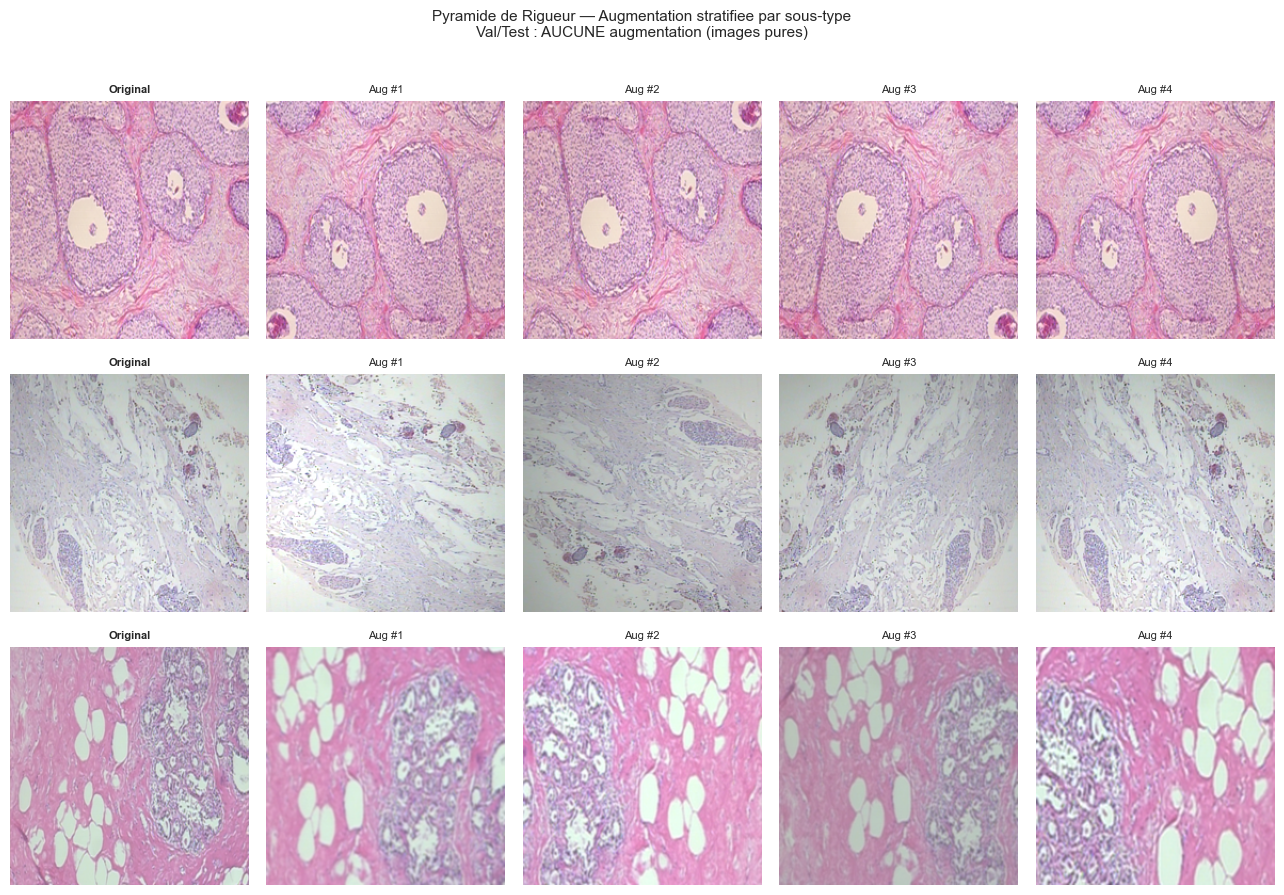


=== Impact de la Pyramide d'Augmentation (set Train uniquement) ===



,tier,facteur,images_avant,images_apres,gain
subtype,,,,,
adenosis,intensif,10,191,1910,1719
phyllodes_tumor,intensif,10,393,3930,3537
papillary_carcinoma,modere,4,408,1632,1224
lobular_carcinoma,intensif,10,427,4270,3843
tubular_adenoma,intensif,10,440,4400,3960
mucinous_carcinoma,modere,4,521,2084,1563
fibroadenoma,leger,2,671,1342,671
ductal_carcinoma,leger,2,2475,4950,2475


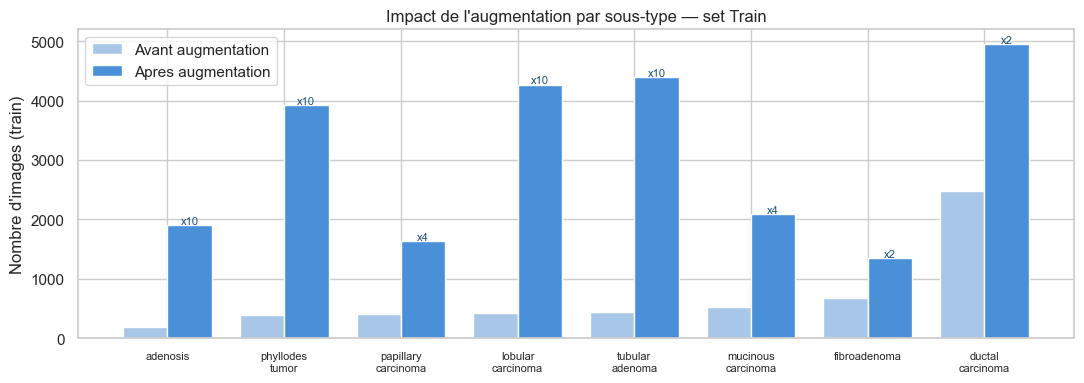


Rappel — Val/Test : pretraitement deterministe UNIQUEMENT
  Val/Test = Resize(256) + CenterCrop(224) + Normalisation ImageNet
  AUCUNE augmentation aleatoire → evaluation reproductible


In [13]:
# Étape 4c — Augmentation : La Pyramide de Rigueur
from PIL import ImageFilter

# ── Fonctions d'augmentation par palier ──────────────────────────────────────

def augLight(img: Image.Image) -> Image.Image:
    """Leger (x2) : Flips H/V uniquement.
    Classes : ductal_carcinoma, fibroadenoma
    Justification : classe dominante — on diversifie sans sur-representer."""
    if random.random() > 0.5: img = ImageOps.mirror(img)
    if random.random() > 0.5: img = ImageOps.flip(img)
    return img

def augModerate(img: Image.Image) -> Image.Image:
    """Modere (x4) : Flips + Rotations 90deg + ColorJitter leger.
    Classes : mucinous_carcinoma, papillary_carcinoma
    Justification : invariance spatiale + simulation ecarts de coloration inter-labo."""
    img = augLight(img)
    img = img.rotate(random.choice([0, 90, 180, 270]))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.80, 1.20))
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.85, 1.15))
    return img

def augIntensive(img: Image.Image) -> Image.Image:
    """Intensif (x10+) : Flips + Rotations + RandomResizedCrop + GaussianBlur.
    Classes : adenosis, lobular_carcinoma, phyllodes_tumor, tubular_adenoma
    Justification : classes rares (1-3 patients) — le modele doit les voir
    sous toutes les coutures pour generaliser."""
    img = augModerate(img)
    # RandomResizedCrop — force le modele a voir des details a differentes echelles
    W, H  = img.size
    scale = random.uniform(0.30, 0.90)
    cw    = max(int(W * scale), 64)
    ch    = max(int(H * scale), 64)
    x     = random.randint(0, W - cw)
    y     = random.randint(0, H - ch)
    img   = img.crop((x, y, x + cw, y + ch)).resize((W, H), Image.LANCZOS)
    # GaussianBlur tres leger — simule des variations de mise au point
    img   = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.1, 1.2)))
    return img

AUG_FN = {"leger": augLight, "modere": augModerate, "intensif": augIntensive}


if not df.empty:
    # ── Grille visuelle : 3 paliers x 5 colonnes (original + 4 augmentations) ─
    TIER_EXAMPLES = [
        ("leger",    "ductal_carcinoma",   "Leger (x2)"),
        ("modere",   "mucinous_carcinoma", "Modere (x4)"),
        ("intensif", "adenosis",           "Intensif (x10+)"),
    ]
    nCols = 5   # original + 4 variantes
    fig, axes = plt.subplots(3, nCols, figsize=(nCols * 2.6, 9))

    for row, (tier, subtype, tier_label) in enumerate(TIER_EXAMPLES):
        sub = df[(df["subtype"] == subtype) & (df["split"] == "train") & (df["magnification"] == 40)]
        if sub.empty:
            sub = df[(df["subtype"] == subtype) & (df["magnification"] == 40)]
        path = sub.iloc[0]["imagePath"]
        orig = Image.open(path).convert("RGB")
        orig_resized = orig.resize((CROP_SIZE, CROP_SIZE), Image.LANCZOS)
        aug_fn = AUG_FN[tier]

        axes[row, 0].imshow(orig_resized)
        axes[row, 0].set_title("Original", fontsize=8, fontweight="bold")
        axes[row, 0].set_ylabel(
            f"{tier_label}\n{subtype.replace('_', ' ')}", fontsize=8, labelpad=6)
        axes[row, 0].axis("off")

        for col in range(1, nCols):
            aug_img = aug_fn(orig_resized.copy())
            axes[row, col].imshow(aug_img)
            axes[row, col].set_title(f"Aug #{col}", fontsize=8)
            axes[row, col].axis("off")

    fig.suptitle(
        "Pyramide de Rigueur — Augmentation stratifiee par sous-type\n"
        "Val/Test : AUCUNE augmentation (images pures)", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Tableau d'impact : images avant / apres augmentation par sous-type ────
    print("\n=== Impact de la Pyramide d'Augmentation (set Train uniquement) ===\n")
    trainDf = df[df["split"] == "train"] if "split" in df.columns else df
    impact  = (trainDf.groupby("subtype")
                      .size()
                      .rename("images_avant")
                      .reset_index())
    impact["tier"]          = impact["subtype"].map(AUG_TIERS)
    impact["facteur"]       = impact["tier"].map(AUG_FACTOR)
    impact["images_apres"]  = impact["images_avant"] * impact["facteur"]
    impact["gain"]          = impact["images_apres"] - impact["images_avant"]
    impact = impact.sort_values("images_avant")

    from IPython.display import display
    display(impact[["subtype", "tier", "facteur", "images_avant", "images_apres", "gain"]]
            .set_index("subtype"))

    # Graphe avant / apres
    fig2, ax = plt.subplots(figsize=(11, 4))
    x    = np.arange(len(impact))
    w    = 0.38
    ax.bar(x - w/2, impact["images_avant"], w, label="Avant augmentation", color="#a8c7e8")
    ax.bar(x + w/2, impact["images_apres"], w, label="Apres augmentation",  color="#4a90d9")
    ax.set_xticks(x)
    ax.set_xticklabels(impact["subtype"].str.replace("_", "\n"), fontsize=8)
    ax.set_ylabel("Nombre d'images (train)")
    ax.set_title("Impact de l'augmentation par sous-type — set Train")
    ax.legend()
    # Annotations facteur
    for xi, (_, r) in zip(x, impact.iterrows()):
        ax.text(xi + w/2, r["images_apres"] + 20, f'x{r["facteur"]}',
                ha="center", fontsize=8, color="#1a5276")
    plt.tight_layout()
    plt.show()

    # Verification : Val et Test ne recoivent pas d'augmentation
    print("\nRappel — Val/Test : pretraitement deterministe UNIQUEMENT")
    print("  Val/Test = Resize(256) + CenterCrop(224) + Normalisation ImageNet")
    print("  AUCUNE augmentation aleatoire → evaluation reproductible")


NameError: name 'preprocessImage' is not defined

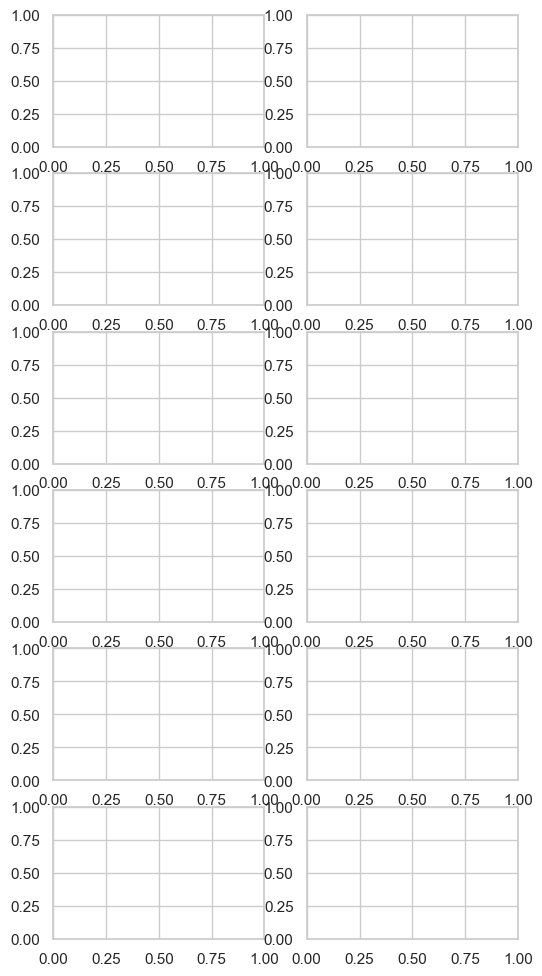

In [14]:
# Étape 4d — Vérification avant / après + histogramme des pixels
if not df.empty:
    nShow = 3
    paths_b = df[df["label"] == 0].sample(nShow, random_state=randomSeed)["imagePath"].tolist()
    paths_m = df[df["label"] == 1].sample(nShow, random_state=randomSeed)["imagePath"].tolist()
    all_paths  = paths_b + paths_m
    all_labels = ["Bénin"] * nShow + ["Malin"] * nShow

    fig, axes = plt.subplots(len(all_paths), 2, figsize=(6, len(all_paths) * 2))
    for i, (path, lbl) in enumerate(zip(all_paths, all_labels)):
        orig = Image.open(path).convert("RGB")
        pre  = preprocessImage(path)
        axes[i, 0].imshow(orig)
        axes[i, 0].set_title(f"Original — {lbl}", fontsize=8)
        axes[i, 0].axis("off")
        axes[i, 1].imshow(pre)
        axes[i, 1].set_title(f"{targetSize} norm. — {lbl}", fontsize=8)
        axes[i, 1].axis("off")
    fig.suptitle("Avant / Après prétraitement", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

    # Histogramme RGB avant / après (sur un exemple)
    path_ex = paths_b[0]
    arr_orig = np.asarray(Image.open(path_ex).convert("RGB"), dtype=np.float32)
    arr_pre  = preprocessImage(path_ex)

    fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4))
    for c, color in enumerate(["tomato", "mediumseagreen", "cornflowerblue"]):
        axes2[0].hist(arr_orig[:,:,c].ravel(), bins=64, alpha=0.55,
                      color=color, label=["R","G","B"][c])
        axes2[1].hist(arr_pre[:,:,c].ravel(), bins=64, alpha=0.55,
                      color=color, label=["R","G","B"][c])
    for ax, title in zip(axes2, ["Valeurs originales (0–255)", "Valeurs normalisées (0–1)"]):
        ax.set_title(title)
        ax.set_ylabel("Fréquence")
        ax.legend()
    fig2.suptitle("Distribution des valeurs RGB — avant / après normalisation")
    plt.tight_layout()
    plt.show()


## Résumé — Pipeline Prétraitement & Augmentation

### Architecture du pipeline (mots-clés rapport)

| Étape | Train | Val / Test | Terme technique |
|---|---|---|---|
| Chargement | `Image.open` + `RGB` | identique | — |
| Redimensionnement | **RandomResizedCrop(224)** | Resize(256) + CenterCrop(224) | *Invariance d'échelle* |
| Augmentation géométrique | Flips H/V + Rotations 90° | **Aucune** | *Invariance spatiale* |
| Augmentation couleur | ColorJitter (contraste, luminosité) | **Aucune** | *Robustesse inter-labo* |
| Augmentation avancée (rares) | RandomResizedCrop + GaussianBlur | **Aucune** | *Augmentation stratifiée* |
| Normalisation | ImageNet (µ=0.485/0.456/0.406, σ=0.229/0.224/0.225) | identique | *Transfer Learning* |

### Justifications clés

**Invariance spatiale** : En microscopie histologique, il n'existe pas de sens de lecture. Une cellule cancéreuse retournée ou pivotée à 90° reste une cellule cancéreuse. Les flips et rotations par angles droits sont donc biologiquement valides et totalement sûrs.

**Augmentation stratifiée** : Plutôt qu'appliquer la même augmentation à toutes les classes, on adapte l'intensité à la rareté du sous-type — de x2 pour le carcinome canalaire (dominant) à x10+ pour l'adénose ou le carcinome lobulaire (1 à 3 patients en train). L'objectif n'est pas d'égaler le volume du ductal carcinoma, mais de **réduire l'écart de moitié**.

**Data Leakage Prevention** : Le split est réalisé **au niveau patient** avant toute augmentation. Aucune image augmentée d'un patient train ne peut se retrouver dans val ou test. L'étanchéité du split est vérifiée par assertion à chaque exécution.

**Pénalisation par fréquence inverse** : Le `class_weight` est calculé **uniquement sur le set Train** (jamais sur val/test pour ne pas introduire de biais). Formule : `w_i = n_total / (n_classes * n_i)`. Résultat : la classe bénigne (minoritaire) est ~2x plus pénalisante que la classe maligne lors du calcul de la loss.

**RandomResizedCrop vs Resize direct** : Un redimensionnement brutal 700×460 → 224×224 compresse les détails nucléaires critiques pour la détection du carcinome. Le crop aléatoire permet au modèle de voir des **détails à la bonne échelle** tout en créant de la diversité à chaque passage (epoch).

## Étape 5 — Gestion du déséquilibre de classes

**Contexte BreakHis :** ~2 480 bénins (0) vs ~5 429 malins (1) → ratio ~1 : 2.2

Dans un contexte médical, un **faux négatif** (cancer non détecté) est bien plus grave qu'un faux positif. La stratégie est donc de maximiser le **recall (sensibilité) sur la classe maligne**, sans sacrifier entièrement la précision.

Trois axes complémentaires, à combiner progressivement :

| Axe | Technique | Quand l'utiliser |
|---|---|---|
| 1 | `class_weight` (pondération de la loss) | Toujours — baseline obligatoire |
| 2 | `WeightedRandomSampler` (batches équilibrés) | Si biais résiduel après axe 1 |
| 3 | Focal Loss | Si fine-tuning CNN profond |

In [ ]:
# ── Axe 1 : Pondération des classes ──────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import display

if not df.empty:
    # class_weight calcule sur le TRAIN uniquement (apres split patient, avant augmentation)
    # Pour une augmentation aleatoire a chaque epoch, les stats de base restent stables
    if "split" in df.columns:
        trainDf = df[df["split"] == "train"]
        print(f"class_weight calcule sur le split TRAIN ({len(trainDf):,} images, avant augmentation)")
    else:
        trainDf = df
        print("ATTENTION : colonne 'split' absente — relancer la cellule de split d'abord.")
        print(f"class_weight calcule sur le dataset complet ({len(trainDf):,} images) par defaut.")

    labels_arr = trainDf["label"].values
    weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=labels_arr)
    classWeight = {0: float(weights[0]), 1: float(weights[1])}

    nBenin = int((labels_arr == 0).sum())
    nMalin = int((labels_arr == 1).sum())
    print(f"\n=== Axe 1 — class_weight (penalisation par frequence inverse) ===")
    print(f"  Benin  (0) : {nBenin:,} images  poids = {classWeight[0]:.4f}  (penalise, minorite)")
    print(f"  Malin  (1) : {nMalin:,} images  poids = {classWeight[1]:.4f}")
    print(f"  Ratio reel : 1 : {nMalin/nBenin:.2f}  (malin / benin sur le train)")
    print()
    print("Utilisation :")
    print("  Keras   -> model.fit(..., class_weight=classWeight)")
    print("  PyTorch -> nn.CrossEntropyLoss(weight=torch.tensor([w0, w1]))")


# ── Axe 2 : WeightedRandomSampler (batches équilibrés — PyTorch) ──────────────
print()
print("=== Axe 2 — WeightedRandomSampler ===")
if not df.empty:
    sampleWeights = [classWeight[l] for l in df["label"].values]

    code_sampler = """
from torch.utils.data import WeightedRandomSampler, DataLoader

sample_weights = [class_weight[l] for l in train_df["label"]]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,          # remplacement → oversampling naturel bénin
)
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
"""
    print(code_sampler.strip())
    print()

    # Simulation : distribution des batches avec vs sans sampler
    n_batches  = 20
    batch_size = 32
    rng = np.random.default_rng(randomSeed)

    counts_unweighted = []
    counts_weighted   = []
    prob_weighted = np.array([classWeight[l] for l in df["label"].values])
    prob_weighted = prob_weighted / prob_weighted.sum()

    for _ in range(n_batches):
        idx_uw = rng.choice(len(df), size=batch_size, replace=False)
        idx_w  = rng.choice(len(df), size=batch_size, replace=True, p=prob_weighted)
        counts_unweighted.append((df["label"].values[idx_uw] == 0).sum())
        counts_weighted.append((df["label"].values[idx_w]   == 0).sum())

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].bar(range(n_batches), counts_unweighted, color="#e07b54", label="Bénins / batch")
    axes[0].axhline(np.mean(counts_unweighted), ls="--", color="black", label=f"Moy. {np.mean(counts_unweighted):.1f}")
    axes[0].set_title("Sans WeightedSampler")
    axes[0].set_xlabel("Batch #")
    axes[0].set_ylabel("Nb bénins")
    axes[0].legend()

    axes[1].bar(range(n_batches), counts_weighted, color="#4a90d9", label="Bénins / batch")
    axes[1].axhline(np.mean(counts_weighted), ls="--", color="black", label=f"Moy. {np.mean(counts_weighted):.1f}")
    axes[1].set_title("Avec WeightedRandomSampler")
    axes[1].set_xlabel("Batch #")
    axes[1].set_ylabel("Nb bénins")
    axes[1].legend()

    fig.suptitle(f"Simulation sur {n_batches} batches de {batch_size} images", fontsize=11)
    plt.tight_layout()
    plt.show()


# ── Axe 3 : Focal Loss ────────────────────────────────────────────────────────
print()
print("=== Axe 3 — Focal Loss (PyTorch) ===")

focal_code = """
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 0.75, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha   # poids classe bénigne (minorité)
        self.gamma = gamma   # focus sur exemples difficiles (2.0 = standard)

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce = F.cross_entropy(inputs, targets, reduction="none")
        pt = torch.exp(-ce)                         # probabilité de la bonne classe
        focal = self.alpha * (1 - pt) ** self.gamma * ce
        return focal.mean()

# Utilisation :
# criterion = FocalLoss(alpha=0.75, gamma=2.0)
# loss = criterion(model_output, labels)
"""
print(focal_code.strip())

# Visualisation de l'effet gamma sur le poids accordé aux exemples faciles
fig, ax = plt.subplots(figsize=(7, 4))
pt_vals = np.linspace(0.01, 0.99, 200)
for gamma in [0, 0.5, 1, 2, 5]:
    ax.plot(pt_vals, (1 - pt_vals) ** gamma, label=f"gamma={gamma}")
ax.set_xlabel("pt  (probabilité de la bonne classe)")
ax.set_ylabel("Facteur de pondération (1 - pt)^gamma")
ax.set_title("Focal Loss — effet de gamma sur les exemples faciles")
ax.legend()
plt.tight_layout()
plt.show()


# ── Axe 4 : Métriques adaptées ───────────────────────────────────────────────
print()
print("=== Axe 4 — Métriques d'évaluation adaptées ===")
from sklearn.metrics import classification_report, roc_auc_score, matthews_corrcoef

if not df.empty:
    # Simulation d'un classifieur majoritaire naïf (prédit toujours 1 = malin)
    y_true  = df["label"].values
    y_naive = np.ones(len(y_true), dtype=int)
    y_proba_naive = np.column_stack([np.zeros(len(y_true)), np.ones(len(y_true))])

    print("Classifieur naïf (prédit toujours 'malin') :")
    print(classification_report(y_true, y_naive, target_names=["Benin (0)", "Malin (1)"]))
    try:
        auc = roc_auc_score(y_true, y_proba_naive[:, 1])
    except Exception:
        auc = float("nan")
    mcc = matthews_corrcoef(y_true, y_naive)
    print(f"AUC-ROC : {auc:.4f}   (0.5 = aléatoire)")
    print(f"MCC     : {mcc:.4f}   (0 = aléatoire, 1 = parfait)")
    print()
    print("Métriques à surveiller en priorité :")
    print("  1. Recall classe 1 (Malin)  → minimiser les faux négatifs")
    print("  2. F1-Score                 → équilibre précision / rappel")
    print("  3. AUC-ROC                  → robuste au déséquilibre")
    print("  4. MCC                      → métrique la plus équilibrée globalement")

### Prochaine étape — Modélisation

#### 1. Split par patient
Diviser **par patient** (jamais par image) pour éviter le data leakage.
Utiliser `Folds.csv` si disponible, sinon `GroupShuffleSplit` de scikit-learn :
- ~65–66 patients → entraînement
- ~16–17 patients → validation / test

#### 2. DataLoader avec anti-déséquilibre
```
class_weight  →  toujours activé
WeightedRandomSampler  →  si biais résiduel
Augmentation ciblée bénin  →  aug_factor = {0: 3, 1: 1}
```

#### 3. Architectures à tester (dans l'ordre)
| Modèle | Entrée | Contexte |
|---|---|---|
| CNN from scratch (3–5 couches) | 224×224 | Baseline rapide |
| VGG16 fine-tuning | 224×224 | Référence paper (F1 ~95 %) |
| ResNet50 / EfficientNetB0 | 224×224 | Alternative plus légère |

#### 4. Tâches
1. **Binaire** : bénin (0) vs malin (1) — tâche principale
2. **Multi-classes** : 8 sous-types (DC, LC, MC, PC, A, F, PT, TA) — tâche avancée

#### 5. Gestion du déséquilibre (implémenté à l'étape 5)
- **Baseline** : `class_weight="balanced"` + métriques F1 / AUC / Recall
- **Niveau 2** : `WeightedRandomSampler` + augmentation ciblée bénin
- **Niveau 3** : `FocalLoss(alpha=0.75, gamma=2.0)` si biais persistant

#### 6. Métriques de suivi (ordre de priorité)
1. Recall classe Malin (1) — sensibilité, minimiser faux négatifs
2. F1-Score macro
3. AUC-ROC
4. MCC (Matthews Correlation Coefficient)
5. Matrice de confusion complète
